# Занятие 3.
__1. TSNE__

__2. Деревья решений__

__3. Overfitting__

__4. Методы валидации данных и выбора модели__

__5. kNN__

__6. Toy datasets__

In [1]:
# Firstly import all required packages
# enable interactive mode of matplotlib
%matplotlib notebook

# import cv2  # python OpenCV
import os  # 
import numpy as np  # lib for arrays
import datetime
import glob
import pandas as pd

import math as mh  # math package

import matplotlib as mpl  
import matplotlib.pyplot as plt  # namespace for plotting
mpl.rcParams['figure.figsize'] = (6,5)  # change default value of plot size

# matplotlib based package for pretty visualization
import seaborn as sns
plt.style.use('seaborn')
from sklearn.datasets import load_iris

import time
import pickle  # package for dump & load data
import warnings

tips = sns.load_dataset("tips")

# Первые шаги в Scikit-Learn

Как быть, если мы хотим подсмотреть на данные, которые представлены в `N` мерном признаковом пространстве, но хочется отразить их на двумерное для большей наглядности?

Существует возможность представления данных через **[t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)** (t-distributed stochastic neighbor embedding). Для корректной работы алгоритма необходимо также выполнить предварительное масштабирование признаков к одинаковому интервалу, что может быть достигнуто с помощью функции **[StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)**.

In [2]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

In [3]:
iris = load_iris()
feature_names = [feat[:-5] for feat in iris['feature_names']]
df_iris = pd.DataFrame(iris['data'], columns=feature_names)
df_iris = pd.concat([df_iris, pd.DataFrame({'target': np.array(iris['target'])}, dtype=int)], axis=1)  # axis=1 - concat along columns
df_iris['target'] = df_iris['target'].map(lambda x: iris.target_names[x])

In [4]:
X = df_iris.drop(['target'], axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
tsne = TSNE(random_state=17)
tsne_representation = tsne.fit_transform(X_scaled)

In [6]:
plt.figure()
plt.scatter(x=tsne_representation[:, 0], 
            y=tsne_representation[:, 1], 
            c=df_iris['target'].map({'setosa': 'k', 'virginica': 'm', 'versicolor': 'g'}));

<IPython.core.display.Javascript object>

Вот пример, как можно поиграться с различными параметрами **[t-SNE](https://distill.pub/2016/misread-tsne/)**.

# <center> Деревья решений </center>
<img src="images/tree.jpeg"/>

__Дерево решений__ – это модель, представляющая собой совокупность правил для принятия решений.

Графически её можно представить в виде древовидной структуры, где моменты принятия решений соответствуют так называемым узлам (_decision  nodes_). В узлах происходит ветвление процесса (_branching_), т.е.  деление его на так называемые ветви (_branches_) в зависимости от сделанного выбора. Конечные (или, что то же самое, терминальные) узлы называют листьями (_leafs, leafnodes_), где каждый лист – это конечный результат последовательного принятия решений.

Построение дерева основано на приросте информации в каждом узле, т.е. уменьшении энтропии Шеннона:

$$ S=-\sum_{i}^{N}{p_i\,log_2 p_i} $$

Уменьшение энтропии при разбиении по признаку _Q_ оценивается с помощью прироста информации (Information Gain - IG):

$$ IG(Q) = S_{0} - \sum_{i=1}^{q}\dfrac{N_i}{N} S_{i} $$

[Официальная документация Scikit-Learn Decision Trees](https://scikit-learn.org/stable/modules/tree.html)

# Overfitting [Bishop]
Сгенерируем функцию синуса на отрезке $[0, 1]$, предварительно добавив к ней шум:

In [7]:
random_seed = 90

In [8]:
np.random.seed(random_seed) # set seed for reproducable data
x_sin = np.linspace(0, 1, 10)  # x values
y_sin = np.sin(x_sin * 2 * np.pi) + np.random.randn(x_sin.size) * 0.3

In [9]:
np.random.seed(random_seed)
x_plot = np.linspace(0, 1, 100000)
y_test = np.sin(x_plot * 2 * np.pi) + np.random.randn(x_plot.size) * 0.3

In [10]:
plt.figure(figsize=(9, 9))
plt.plot(x_plot, np.sin(x_plot * 2 * np.pi), color='r', linewidth=2.0)
plt.scatter(x_sin, y_sin, color='darkgreen')
plt.legend(['Target', 'Noisy data'])
plt.grid(linewidth=0.2)

<IPython.core.display.Javascript object>

Пусть будем искать представление искомой функции в полиномиальной форме:

$$ y(x, \textbf{w}) = w_0 + w_1\,x + w_2\,x + \dots + w_M\,x^M = \sum_{j=0}^{M} w_j\,x^j,$$
где $ M $ - порядок полинома, $ w_j $ коэффициенты полинома.

Функция $ y(x, \textbf{w}) $ нелинейна относительно $ x^j $, но линейна относительно коэффицентов $ w_j $. Такие модели, в которых обучаемые параметры (коэффициенты в данном случае) называются __линейными__. 

Значения коэффициентов $ w_j $ могут быть получены за счет аппроксимации полиномом исходных данных. Аппроксимая данных полиномом производится согласно уменьшению ошибки аппроксимации $ E $. Такой ошибкой часто выступает квадратичная функция потерь:

$$ E(\textbf{w}) = \dfrac{1}{2} \sum_{n=1}^{N} (y(x_n, \textbf{w}) - t_n)^2, $$ 
где $ N $ - размер данных.

Аппроксимая данных в данном случае будет производиться так, чтобы уменьшить расстояние между каждой точкой из наблюдаемых данных и значением, предсказанным моделью. Существует значение $ w^* $, которое является минимумом функции $ E(\textbf{w}) $. Тогда функция $ y(x, \textbf{w^*}) $ будет удовлетворять условию минимума среднеквадратичной ошибки. 

Когда необходимо сравнить ошибку на данных разного размера, оценивают среднеквадратичное отклонение ошибки:
$$E_{RMS} = \sqrt{\dfrac{2E\textbf(w^*)}{N}}$$

Но какое значение степени полинома $ M $ следует выбрать? Рассмотрим значения полинома $ M = 0, 1, 2, 3, 9 $.

In [11]:
# import sklearn regressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge, LinearRegression

In [12]:
m_values = np.arange(10)
y_m = {'train': {}, 
       'test': {}}
models = {}
for m in m_values:
    poly = PolynomialFeatures(degree=m)
    poly_ = poly.fit_transform(x_sin.reshape(-1, 1))
    x_plot_ = poly.fit_transform(x_plot.reshape(-1, 1))
    lg = LinearRegression()
    lg.fit(poly_, y_sin)
    models[m] = lg
    y_m['test'][m] = lg.predict(x_plot_)
    y_m['train'][m] = lg.predict(poly.fit_transform(x_sin.reshape(-1, 1)))

<IPython.core.display.Javascript object>


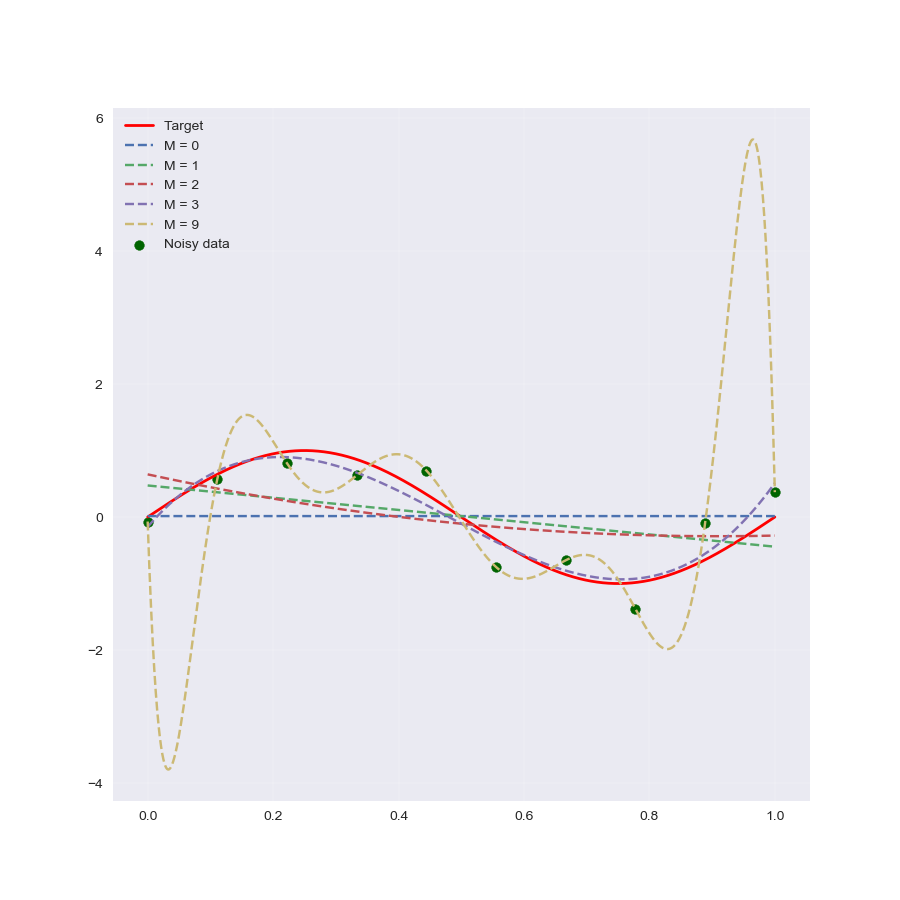

In [30]:
plt.figure(figsize=(9, 9))
plt.plot(x_plot, np.sin(x_plot * 2 * np.pi), color='r', linewidth=2.0)
m_except = list(range(4, 9))

for m in m_values:
    if m not in m_except:
        plt.plot(x_plot, y_m['test'][m], linestyle='--')
plt.scatter(x_sin, y_sin, color='darkgreen')

plt.legend(['Target', *('M = ' + str(i) for i in m_values if i not in m_except), 'Noisy data'])
plt.grid(linewidth=0.2)

Вычислим $E_{RMS}$ для каждого из значений степени полинома в случае обучающей *(x_sin, y_sin)* и тестовой выборки *(x_plot, y_test)*:

In [14]:
# define E_rms function
def e_rms(y_true, y_pred):
    return np.sqrt(np.sum((y_true - y_pred)**2)/y_true.size)

error_rms = {'train': {}, 
             'test': {}}
for m in m_values:
    error_rms['train'][m] = e_rms(y_sin, y_m['train'][m])
    error_rms['test'][m] = e_rms(y_test, y_m['test'][m])

И построим графики значений $ E_{RMS} $ от значения степени полинома для обучающей и тестовой выборок:

<IPython.core.display.Javascript object>


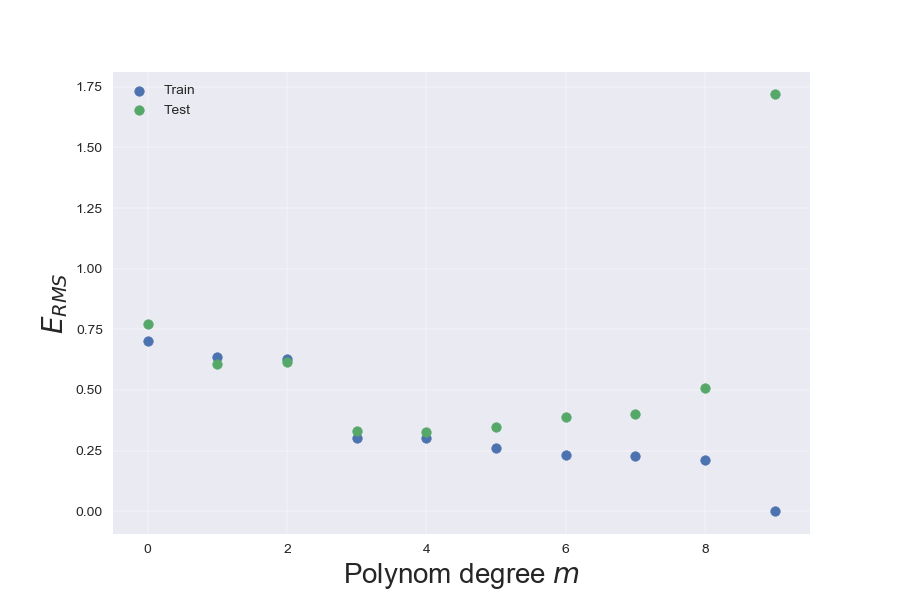

In [29]:
plt.figure(figsize=(9, 6))
plt.scatter(m_values, np.array([v for k, v in error_rms['train'].items()]))
plt.scatter(m_values, np.array([v for k, v in error_rms['test'].items()]))
plt.legend(['Train', 'Test'])
plt.xlabel(r'Polynom degree $ m$', fontsize=20)
plt.ylabel(r'$E_{RMS}$', fontsize=20)
plt.grid(linewidth=0.3)

Сделаем выводы по графику:
* Ошибка на train упала до 0 в случае $ M = 9 $, модель при этом абсолютно точно аппроксимировала данные. Ошибка на тестовой выборке резко возросла.
* Качественную аппроксимацию данных обеспечивают порядки полинома от 3 до 8

Что же происходит с весами полинома при этом? Посмотрим на них:


In [16]:
for m in m_values:
    print('Model with degree M={}'.format(m))
    for n_w, weight in enumerate(models[m].coef_):
        print('w_{} = {:.2f}'.format(n_w, weight), end=' ')
    print()

Model with degree M=0
w_0 = 0.00 
Model with degree M=1
w_0 = 0.00 w_1 = -0.92 
Model with degree M=2
w_0 = 0.00 w_1 = -2.05 w_2 = 1.13 
Model with degree M=3
w_0 = 0.00 w_1 = 10.96 w_2 = -33.16 w_3 = 22.86 
Model with degree M=4
w_0 = 0.00 w_1 = 10.13 w_2 = -28.95 w_3 = 16.12 w_4 = 3.37 
Model with degree M=5
w_0 = 0.00 w_1 = 0.99 w_2 = 47.21 w_3 = -199.17 w_4 = 250.14 w_5 = -98.71 
Model with degree M=6
w_0 = 0.00 w_1 = 13.03 w_2 = -101.34 w_3 = 440.18 w_4 = -985.40 w_5 = 1000.33 w_6 = -366.34 
Model with degree M=7
w_0 = 0.00 w_1 = 6.86 w_2 = 0.43 w_3 = -163.28 w_4 = 720.93 w_5 = -1488.00 w_6 = 1439.45 w_7 = -515.94 
Model with degree M=8
w_0 = 0.00 w_1 = 43.64 w_2 = -741.26 w_3 = 5430.93 w_4 = -20382.90 w_5 = 42448.14 w_6 = -49819.38 w_7 = 30867.01 w_8 = -7845.74 
Model with degree M=9
w_0 = 0.00 w_1 = -274.30 w_2 = 6602.55 w_3 = -60717.41 w_4 = 290373.16 w_5 = -804166.80 w_6 = 1336461.31 w_7 = -1313739.15 w_8 = 703548.74 w_9 = -158087.66 


Значения коэффициентов возрастают с увеличением степени полинома, а модель пытается аппроксимровать шумовые значения. Это явление называется **`overfitting`**.

Обучим модель со степенью полинома 9, но увеличим обучающую выборку до 100 значений:

In [25]:
np.random.seed(random_seed)
x_train = np.linspace(0, 1, 100)
y_train = np.sin(2 * np.pi * x_train) + np.random.randn(x_train.size) * 0.3

Построим график и посмотрим, как обучилась в таком случае модель:

In [26]:
poly = PolynomialFeatures(degree=9)
poly_ = poly.fit_transform(x_train.reshape(-1, 1))
lg = LinearRegression()
lg.fit(poly_, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

<IPython.core.display.Javascript object>


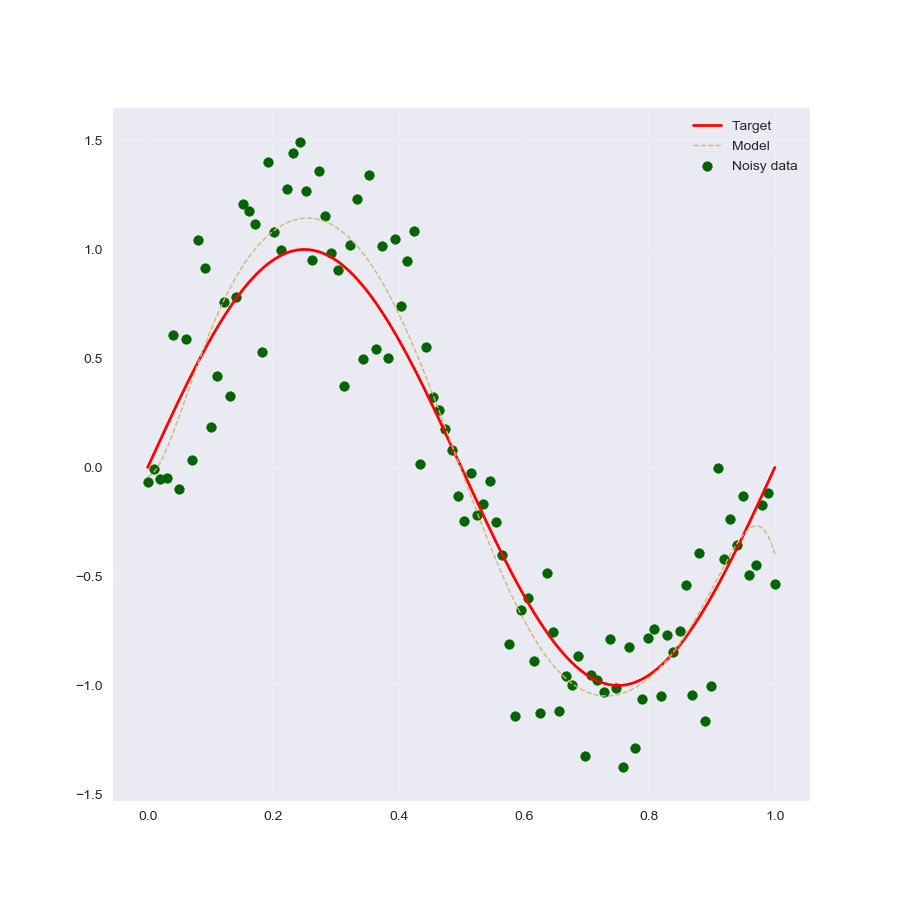

In [28]:
plt.figure(figsize=(9, 9))
plt.plot(x_plot, np.sin(x_plot * 2 * np.pi), color='r', linewidth=2.0)
plt.scatter(x_train, y_train, color='darkgreen')

plt.plot(x_plot, lg.predict(poly.fit_transform(x_plot.reshape(-1, 1))), color='C4', linewidth=1.0, linestyle='--')

plt.legend(['Target', 'Model', 'Noisy data'])
plt.grid(linewidth=0.2)

Увеличеие количества данных делает модель более гибкой - она приобретает способность более качественно обобщаться на новые данные (**`generalization`**). Но что делать, если возможности увеличение датасета не существует? Можно воспользоваться различными методиками, одной из которых является **регуляризация**.

Регуляризация штрафут функцию потерь во избежание увеличения значений весов:<br><br>
$$ E(\textbf{w}) = \dfrac{1}{2} \sum_{n=1}^{N} (y(x_n, \textbf{w}) - t_n)^2 + \dfrac{\lambda}{2}\|\textbf{w}^2\|, $$ 
где $ \|\textbf{w}^2\| = \textbf{w}^\intercal \textbf{w} = w_0 + w_1\,x + w_2\,x + \dots + w_M\,x^M $,

$\lambda$ - коэффициент регуляризации, который показывает важность между компонентой среднеквадратичной ошибкой и величиной штрафа. 

Такой случай регуляризации в случае линейной регрессии получил своё название **Ridge Regression** (гребневая регрессия) или **метод регуляризации Тихонова**.


# Методы валидации данных и выбора модели?

Во время обучения возникают вопросы:
* Какую модель выбрать?

Хорошая обученная модель умеет корректно предсказывать не виданные ранее данные. Сама модель должны обладать хорошей предсказательной способностью в рамках заданных метрик. А среди различных моделей необходимо сравнить их качество.

* Какой набор гиперпараметров модели использовать?

Каждая из обучаемых моделей обладает своим набором гиперпараметров. Для каждой модели их может быть несколько штук.

Ответ на все эти вопросы - **кросс валадиция**.

Предположения:
* Данные распределены i.i.d. (independetn and identically distributed)





# kNN - метод ближайших соседей

kNN - метод классификации и регресии. Он основан на следующем интуитивном предположении: какие соседи, такой и ты. Метод отнсится к классу метрических, т.е. на соседей смотрим на основе функции расстояния в признаковом пространстве. 

__Проблема выбора метрики.__ Основной проблемой kNN является выбор метрики, которая должна удовлетворять гипотезе компактности: выбор метрики должен однозначно определить схожие примеры к одному классу.
Популярные метрики - Евклидово расстояние, косинусное расстояние, расстояние Минковского.

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from matplotlib.colors import ListedColormap

In [21]:
from sklearn.datasets import make_moons, make_circles, make_classification
n_samples = 150
X, y = make_classification(n_samples=n_samples, n_features=2, n_redundant=0, n_informative=2,
                           random_state=1, n_clusters_per_class=1)
rng = np.random.RandomState(2)
X += 2 * rng.uniform(size=X.shape)
linearly_separable = (X, y)

datasets = [make_moons(n_samples=n_samples, noise=0.1, random_state=0),
            make_circles(n_samples=n_samples, noise=0.1, factor=0.3, random_state=1),
            linearly_separable]

Плюсы:
* Простая реализация
* Хорошо изучен

Минусы:
* Метод считается быстрым в сравнении, например, с композициями алгоритмов, но в реальных задачах, как правило, число соседей, используемых для классификации, будет большим (100-150), и в таком случае алгоритм будет работать не так быстро, как дерево решений
* Если в наборе данных много признаков, то трудно подобрать подходящие веса и определить, какие признаки не важны для классификации/регрессии
* Проблема выбора метрики
* Выбор числа соседей
* Неустойчив к выбросам
* Необходимость масштабирования

 Воспроизведём [пример](https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html#sphx-glr-auto-examples-classification-plot-classifier-comparison-py) из библиотеки `scikit-learn` и посмотрим, как отрабатывают модели DecisionTree и kNN на разных примерах.

<IPython.core.display.Javascript object>


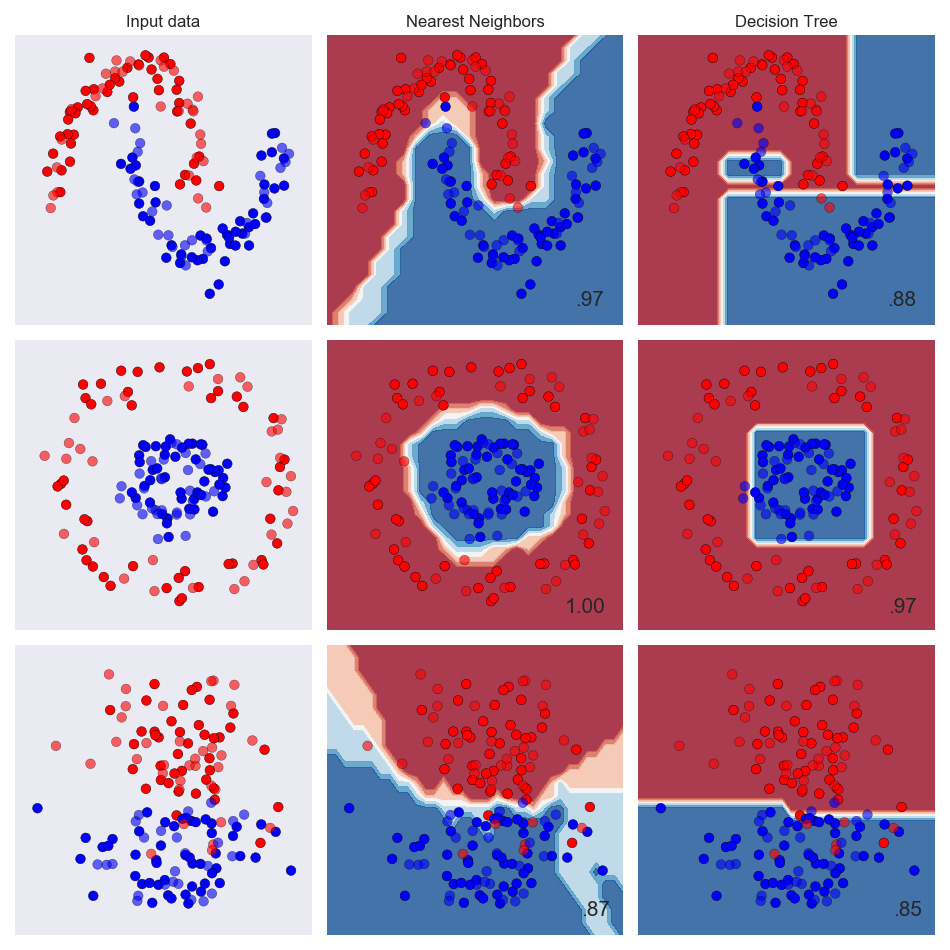

In [23]:
fig, ax = plt.subplots(1, 3, figsize=(9.5, 9.5))
ax = ax.ravel()

names = ["Nearest Neighbors", "Decision Tree"]
classifiers = [KNeighborsClassifier(3), DecisionTreeClassifier(max_depth=5)]

i = 1
h=0.2
# iterate over datasets
for ds_cnt, ds in enumerate(datasets):
    # preprocess dataset, split into training and test part
    X, y = ds
    X = StandardScaler().fit_transform(X)
    X_train, X_test, y_train, y_test = \
        train_test_split(X, y, test_size=.4, random_state=42)

    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # just plot the dataset first
    cm = plt.cm.RdBu
    cm_bright = ListedColormap(['#FF0000', '#0000FF'])
    ax = plt.subplot(len(datasets), len(classifiers) + 1, i)
    if ds_cnt == 0:
        ax.set_title("Input data")
    # Plot the training points
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright,
               edgecolors='k')
    # Plot the testing points
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, alpha=0.6,
               edgecolors='k')
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_xticks(())
    ax.set_yticks(())
    i += 1

    # iterate over classifiers
    for name, clf in zip(names, classifiers):
        ax = plt.subplot(len(datasets), len(classifiers) + 1, i)
        clf.fit(X_train, y_train)
        score = clf.score(X_test, y_test)

        # Plot the decision boundary. For that, we will assign a color to each
        # point in the mesh [x_min, x_max]x[y_min, y_max].
        if hasattr(clf, "decision_function"):
            Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
        else:
            Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]

        # Put the result into a color plot
        Z = Z.reshape(xx.shape)
        ax.contourf(xx, yy, Z, cmap=cm, alpha=.8)

        # Plot the training points
        ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright,
                   edgecolors='k')
        # Plot the testing points
        ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright,
                   edgecolors='k', alpha=0.6)

        ax.set_xlim(xx.min(), xx.max())
        ax.set_ylim(yy.min(), yy.max())
        ax.set_xticks(())
        ax.set_yticks(())
        if ds_cnt == 0:
            ax.set_title(name)
        ax.text(xx.max() - .3, yy.min() + .3, ('%.2f' % score).lstrip('0'),
                size=15, horizontalalignment='right')
        i += 1

plt.tight_layout()
plt.show()